In [1]:
using ITensorMPS
using ITensors
using Plots
using DelimitedFiles
# using ITensorEntropyTools
using Combinatorics
using Random
using KrylovKit  # Standard Lanczos / Davidson solver for Julia ITensor

In [2]:
function entropy_von_neumann(psi::MPS)
  N = length(psi)
  s = siteinds(psi)
  entropies = []
  for b in 2:N-1
    orthogonalize!(psi, b)
    _,S = svd(psi[b], (siteind(psi, b), linkind(psi, b)))
    SvN = 0.0
    for n in 1:dim(S, 1)
      p = S[n,n]^2
      SvN -= p * log(p)
    end
    push!(entropies, SvN)
  end
  return entropies
end

function antiflatness(psi::MPS)
  N = length(psi)
  s = siteinds(psi)
  afs = []
  for b in 2:N-1
    orthogonalize!(psi, b)
    _,S = svd(psi[b], (siteind(psi, b), linkind(psi, b)))
    t1 = 0.0
    t2 = 0.0
    for n in 1:dim(S, 1)
      p = S[n,n]^2
      t1 += p^3
      t2 += p^2
    end
    push!(afs, t1 - t2^2)
  end
  return afs
end

# Only works for bond dimensions that
# are a power of 2
function nl_magic(psi::MPS)
    N = length(psi)
    s = siteinds(psi)
    mags = []
    for b in 2:N-1
        # Assuming MPS 'psi' and bond 'b'
        orthogonalize!(psi, b)
        U, S, V = svd(psi[b], (linkind(psi,b-1), linkind(psi, b)))
        
        # S contains the Schmidt coefficients (singular values)
        arg = 0.0
        for i in combinations(0:size(S, 1) - 1, 4)
            l1 = S[i[1]+1, i[1]+1]
            l2 = S[i[2]+1, i[2]+1]
            l3 = S[i[3]+1, i[3]+1]
            l4 = S[i[4]+1, i[4]+1]

            i5 = i[1] ⊻ i[2] ⊻ i[3] + 1
            l5 = S[i5, i5]

            i6 = i[1] ⊻ i[2] ⊻ i[4] + 1
            l6 = S[i6, i6]

            i7 = i[1] ⊻ i[3] ⊻ i[4] + 1
            l7 = S[i7, i7]

            i8 = i[2] ⊻ i[3] ⊻ i[4] + 1
            l8 = S[i8, i8]

            arg += l1 * l2 * l3 * l4 * l5 * l6 * l7 * l8
        end

        mag = -log2(arg)
        push!(mags, mag)
    end
    return mags
end

# function mc_sre(psi::MPS)
#   N = length(psi)
#   sites = siteinds(psi)
#   P_1 = ["Id", "X", "Y", "Z"]

#   # Thermalization
#   pstring = rand(P_1, N)
#   for i=1:50
#     s = rand(sites)
    
#   end
# end

nl_magic (generic function with 1 method)

# VQE Interacting Ground State

In [137]:
N_s = 16
s = siteinds("S=1/2", N_s)

h = 1.0
J = 0.5


os = OpSum()
for j=1:N_s
    if j == N_s
        os -= J, "X", j, "X", 1
    else
        os -= J, "X", j, "X", j+1
    end
    os -= h, "Z", j
end
H = MPO(os, s)

psi0 = randomMPS(s; linkdims=2^7)

nsweeps = 15
maxdim = [10,20,100,100,200]
cutoff = [1E-10]
noise = [1E-6]
weight = 50

energy0,psi0 = dmrg(H,psi0;nsweeps,maxdim,cutoff)

gs_af = antiflatness(psi0)
gs_EE = entropy_von_neumann(psi0)

After sweep 1 energy=-17.0164743451223  maxlinkdim=10 maxerr=2.99E-03 time=0.011
After sweep 2 energy=-17.016712480695578  maxlinkdim=15 maxerr=8.49E-11 time=0.007
After sweep 3 energy=-17.01671249217638  maxlinkdim=15 maxerr=9.60E-11 time=0.009
After sweep 4 energy=-17.016712492176737  maxlinkdim=15 maxerr=8.41E-11 time=0.007
After sweep 5 energy=-17.0167124921767  maxlinkdim=15 maxerr=8.41E-11 time=0.008
After sweep 6 energy=-17.016712492176772  maxlinkdim=15 maxerr=8.41E-11 time=0.008
After sweep 7 energy=-17.016712492176723  maxlinkdim=15 maxerr=8.41E-11 time=0.008
After sweep 8 energy=-17.016712492176715  maxlinkdim=15 maxerr=8.41E-11 time=0.007
After sweep 9 energy=-17.016712492176758  maxlinkdim=15 maxerr=8.41E-11 time=0.007
After sweep 10 energy=-17.01671249217678  maxlinkdim=15 maxerr=8.41E-11 time=0.009
After sweep 11 energy=-17.016712492176765  maxlinkdim=15 maxerr=8.41E-11 time=0.021
After sweep 12 energy=-17.01671249217678  maxlinkdim=15 maxerr=8.41E-11 time=0.012
After sw

14-element Vector{Any}:
 0.14465953678752416
 0.1719210038496573
 0.17647861738670872
 0.17742670235350488
 0.17763378101580637
 0.1776805025265417
 0.17769126364600782
 0.17769325371612188
 0.17769126247037462
 0.177680502755876
 0.1776337822038159
 0.17742670251903844
 0.17647861325327113
 0.17192100006964464

# Initial State

In [4]:
function rz(theta::Float64, i::Int, psi::MPS, cutoff::Float64)
    s = siteinds(psi)
    z_i = op("Z", s[i])
    Op = exp(-1im/2 * theta * z_i)
    psi = apply(Op, psi; cutoff)
    return psi
end

function giv_op(theta::Float64, i::Int, j::Int, psi::MPS, cutoff::Float64)
    s = siteinds(psi)
    x_i = op("X", s[i])
    y_i = op("Y", s[i])
    x_j = op("X", s[j])
    y_j = op("Y", s[j])
    Op = x_i * y_j - x_j * y_i
    Op = exp(1im * theta / 2 * Op)
    psi = apply(Op, psi; cutoff)
    return psi
end

giv_op (generic function with 1 method)

In [116]:
thetas_r = [-1.1131502145114254
-1.078208574747303
-1.1931100103753072
-1.2025438772822565
-1.2394340728797313
-1.200853661302416
-1.2815003630904602
-1.0457966903477167
-1.3594484381726235
-0.41525092665695396
-0.26029360275326296
-0.5834009954723677
-1.0816365491767963
-1.4567814639676036
-1.560274462794257]

betas_r = [-2.451388610651801,
-2.9168975367126575,
-1.3023793696025325,
-0.0,
1.3023793696025325,
2.9168975367126575,
2.451388610651801,
-1.9804817092445475,
1.4216801686454896,
-1.7253105921310679,
1.5179758494701052,
-1.5707963267949219,
1.62361680411965,
-1.4162820614587286,
1.7199124849443228,
-1.1611109443452376]

thetas_l = [-1.1663318520236712,
-0.23083592452381746,
-0.24530015120944038,
-0.5816216378192097,
-1.0811501945945567,
-1.4566782071470612,
-1.5602649758201765,
-1.5461995608164998,
-1.5586837296265619,
-1.5560841239465213,
-1.5584550128637873,
-1.5578843495190648,
-1.5584569811667301,
-1.5560891815480875,
-1.5586900911843102]

betas_l = [1.7199124849443224,
-1.416282061458729,
1.6236168041196497,
-1.5707963267949219,
1.517975849470105,
-1.7253105921310685,
1.42168016864549,
-1.9804817092445473,
2.4513886106518012,
2.9168975367126575,
1.3023793696025325,
-0.0,
-1.3023793696025325,
-2.9168975367126575,
-2.4513886106518012,
1.9804817092445473]

16-element Vector{Float64}:
  1.7199124849443224
 -1.416282061458729
  1.6236168041196497
 -1.5707963267949219
  1.517975849470105
 -1.7253105921310685
  1.42168016864549
 -1.9804817092445473
  2.4513886106518012
  2.9168975367126575
  1.3023793696025325
 -0.0
 -1.3023793696025325
 -2.9168975367126575
 -2.4513886106518012
  1.9804817092445473

In [117]:
cutoff = 1E-8
maxdim = 40

# Make an array of 'site' indices
# s = siteinds("S=1/2", N_s)

# State Preparation
n_kr = 7
n_kl = -n_kr
sigma = 3/2

init_state = copy(psi0)

for x in 1:N_s
    init_state = rz(betas_r[x], x, init_state, cutoff)
end
for x in 1:N_s-1
    y = N_s - x
    init_state = giv_op(thetas_r[x], y, y+1, init_state, cutoff)
end
sm = op("X", s[1]) - 1im * op("Y", s[1])
init_state = apply(sm, init_state; cutoff)
for x in 1:N_s-1
    y = N_s - x
    init_state = giv_op(-thetas_r[y], x, x+1, init_state, cutoff)
end
for x in 1:N_s
    init_state = rz(-betas_r[x], x, init_state, cutoff)
end

for x in 1:N_s
    init_state = rz(betas_l[x], x, init_state, cutoff)
end
for x in 1:N_s-1
    y = N_s - x
    init_state = giv_op(thetas_l[x], y, y+1, init_state, cutoff)
end
sm = op("X", s[1]) - 1im * op("Y", s[1])
init_state = apply(sm, init_state; cutoff)
for x in 1:N_s-1
    y = N_s - x
    init_state = giv_op(-thetas_l[y], x, x+1, init_state, cutoff)
end
for x in 1:N_s
    init_state = rz(-betas_l[x], x, init_state, cutoff)
end

[0.03321862628626637, 0.04177506194326164, 0.23229242013966217, 0.5404885427824948, 0.23229254642379382, 0.041775339600711836, 0.03321913265163806, 0.03427437434633668, 0.03321905809041764, 0.04177563563742959, 0.23229295162475144, 0.5404887815976508, 0.23229235448029412, 0.04177528086944676, 0.0332188379853694, 0.03427399525263086]


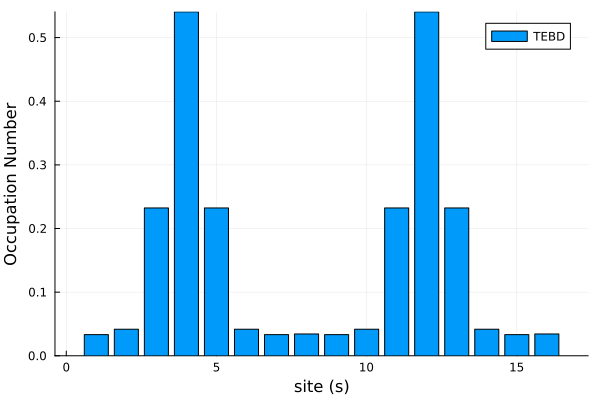

In [118]:
magz = expect(init_state, "Z")
occs = [(1 - magz[n])/2 for n=1:N_s]
println(occs)

sites = [n for n=1:N_s]
plot(bar(sites, occs; label="TEBD"), xlabel="site (s)", ylabel="Occupation Number")

# Time Evolution

In [129]:
# Make Time-Evolution Gates
tau = 0.05
N_t = 200
g = 0.2

gates = ITensor[]
for j in 1:N_s
    s1 = s[j]
    if j == N_s
        s2 = s[1]
    else
        s2 = s[j+1]
    end
    
    x1 = op("X", s1)
    x2 = op("X", s2)

    hxx = -J * x1 * x2

    Gj = exp(-1im * tau * hxx/2)

    push!(gates, Gj)

    hz = - h * op("Z", s1)
    Gj = exp(-1im * tau * hz/2)
    push!(gates, Gj)

    z1 = op("Z", s1)
    z2 = op("Z", s2)

    hzz = -g * z1 * z2

    Gj = exp(-1im * tau * hzz/2)
    push!(gates, Gj)
end

# Include gates in reverse order too
# (N,N-1),(N-1,N-2),...
append!(gates, reverse(gates))

96-element Vector{ITensor}:
 ITensor ord=4
Dim 1: (dim=2|id=158|"S=1/2,Site,n=1")
Dim 2: (dim=2|id=952|"S=1/2,Site,n=2")
Dim 3: (dim=2|id=158|"S=1/2,Site,n=1")'
Dim 4: (dim=2|id=952|"S=1/2,Site,n=2")'
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2×2×2
[:, :, 1, 1] =
 0.9999218760172474 + 0.0im  0.0 + 0.0im
                0.0 + 0.0im  0.0 + 0.012499674481709789im

[:, :, 2, 1] =
                0.0 + 0.0im  0.0 + 0.012499674481709789im
 0.9999218760172474 + 0.0im  0.0 + 0.0im

[:, :, 1, 2] =
 0.0 + 0.0im                   0.9999218760172472 + 0.0im
 0.0 + 0.012499674481709789im                 0.0 + 0.0im

[:, :, 2, 2] =
 0.0 + 0.012499674481709789im                 0.0 + 0.0im
 0.0 + 0.0im                   0.9999218760172472 + 0.0im

 ITensor ord=2
Dim 1: (dim=2|id=158|"S=1/2,Site,n=1")'
Dim 2: (dim=2|id=158|"S=1/2,Site,n=1")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2
 0.9996875162757026 + 0.024997395914712332im  …                -0.0 + 0.0im
               -0.0 + 0.0

In [130]:
# Compute and print <Sz> at each time step
# then apply the gates to go to the next time
maxdim = 128
occs = []
EEs = []
afs = []
nl_mags = []
dims = []
ttotal = N_t * tau
state = deepcopy(init_state)
for t in 0:tau:ttotal
    # println("Pass 1")
    Sz = expect(state, "Z")
    occ = [(1 - Sz[n])/2 for n=1:N_s]
    push!(occs, occ)

    EE = entropy_von_neumann(state)
    push!(EEs, EE)

    af = antiflatness(state)
    push!(afs, af)
    
    nl_mag = nl_magic(state)
    push!(nl_mags, nl_mag)

    bond_dim = maxlinkdim(state)
    push!(dims, bond_dim)
    
    t ≈ ttotal && break

    state = apply(gates, state; cutoff, maxdim)
    normalize!(state)
end

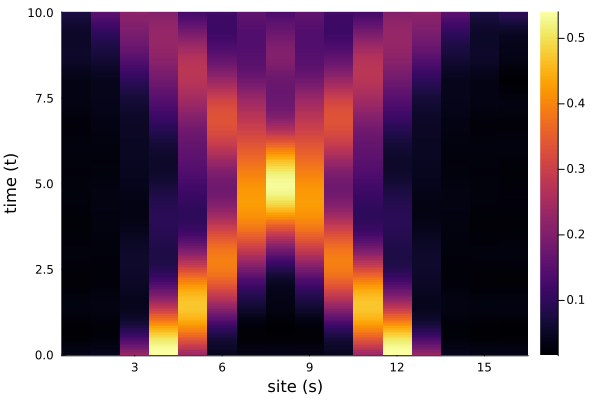

In [131]:
occs_mat = stack(occs, dims=1)

heatmap(1:N_s, 0:tau:(N_t*tau), occs_mat, xlabel="site (s)", ylabel="time (t)")

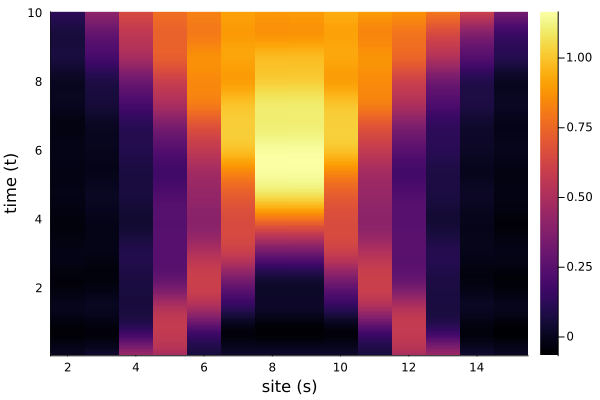

In [138]:
EEs_mat = stack(EEs, dims=1) .- gs_EE'
heatmap(2:N_s-1, tau:tau:(N_t*tau), EEs_mat[2:end,:], xlabel="site (s)", ylabel="time (t)")

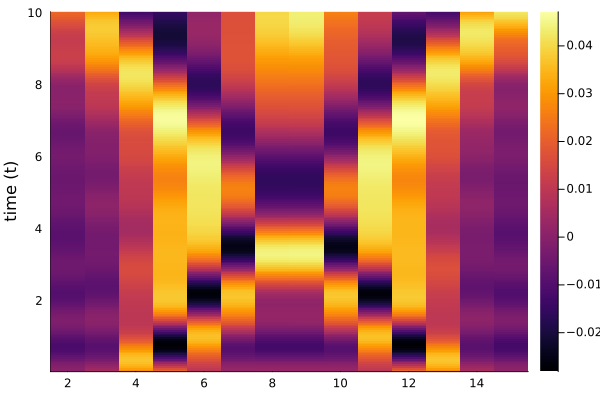

In [139]:
afs_mat = stack(afs, dims=1) .- gs_af'
# afs_mat = stack(afs, dims=1) .- stack(gs_af, dims=1)'
heatmap(2:N_s-1, tau:tau:(N_t*tau), afs_mat[2:end,:], xlabel="", ylabel="time (t)")

In [ ]:
title = "Data/"
title *= "ising-exact-occs-N_s" * string(N_s)
title *= "-J" * string(J)
title *= "-h" * string(h)
title *= "-g" * string(g)
title *= "-width" * string(sigma)
title *= "-dt" * string(tau) * ".txt"
writedlm(title, occs_mat)

In [ ]:
EEs_mat = stack(EEs, dims=1)
title = "Data/"
title *= "ising-exact-EEs-N_s" * string(N_s)
title *= "-J" * string(J)
title *= "-h" * string(h)
title *= "-g" * string(g)
title *= "-width" * string(sigma)
title *= "-dt" * string(tau) * ".txt"
writedlm(title, EEs_mat)